# Day 3 — RNNs & LSTMs for Sequential Data

## ECG Heartbeat Classification Using Recurrent Neural Networks

### Dataset

**ECG Heartbeat Categorization Dataset — MIT-BIH Arrhythmia subset**

Source:
https://www.kaggle.com/datasets/shayanfazeli/heartbeat

### Learning Objectives

By the end of this notebook, we will be able to:

- Explain why sequential data needs an order-aware architecture.
- Explain how an RNN hidden state carries memory across a sequence.
- Explain the vanishing-gradient problem.
- Explain how LSTMs address the vanishing-gradient problem in practice.
- Explain LSTMs and GRUs as gated recurrent architectures.
- Build and train an LSTM on ECG sequential data.
- Compare an LSTM against a plain RNN.
- Evaluate both models using appropriate classification metrics.
- Explain why order-awareness helps ECG classification.

#  Why Does Sequential Data Need a Different Architecture?

Images contain spatial relationships, while ECG signals contain **temporal relationships**.

An ECG is a time-series signal:

x₁ → x₂ → x₃ → ... → x₁₈₇

The order of these values matters.

For example, changing the order of ECG samples changes the waveform itself and can change the meaning of the heartbeat.

Important ECG characteristics such as:

- waveform morphology
- QRS complex
- P wave
- T wave
- transitions between waveform regions

depend on the temporal order of the signal.

Therefore, an ECG classification model should not treat the input values as an unordered collection of numbers.

It should understand:

**what happened before → what is happening now → what happens next**

This motivates the use of sequence-aware architectures such as RNNs and LSTMs.

#  RNNs — Recurrent Neural Networks

A Recurrent Neural Network processes a sequence one element at a time.

At each time step, the RNN receives:

1. The current input `x_t`
2. The hidden state from the previous time step `h_(t-1)`

Conceptually:

h_t = f(x_t, h_(t-1))

The hidden state acts as a form of memory.

For an ECG sequence:

x₁ → h₁
x₂ + h₁ → h₂
x₃ + h₂ → h₃
...
x₁₈₇ + h₁₈₆ → h₁₈₇

This allows the network to use information from earlier samples while processing later samples.

This is what makes an RNN an order-aware architecture.

#  LSTMs — Long Short-Term Memory

An LSTM is a special type of RNN designed to learn long-term dependencies more effectively.

Instead of relying only on a hidden state, an LSTM maintains a memory cell and uses gates to control information flow.

### Forget Gate

Determines what information from the previous memory should be forgotten.

### Input Gate

Determines what new information should be stored.

### Output Gate

Determines what information should be exposed as the current hidden state.

Conceptually:

Previous Memory
      ↓
  Forget Gate
      ↓
Updated Memory
      ↑
  Input Gate
      ↑
New Information
      ↓
  Output Gate
      ↓
Hidden State

The gates are learned during training.

This allows the LSTM to preserve relevant information and discard irrelevant information.

#  GRUs — Gated Recurrent Units

A GRU is another gated recurrent architecture.

GRUs are similar to LSTMs but use a simpler gating mechanism and do not maintain a separate cell state in the same way an LSTM does.

### LSTM
- More explicit memory mechanism
- Forget, input, and output gates
- More parameters

### GRU
- Simpler architecture
- Fewer parameters
- Often faster to train

Both are designed to improve learning of longer-term dependencies compared with a plain RNN.

For today's hands-on task, we will focus on the LSTM.

###  Install KaggleHub


In [ ]:

!pip install -q kagglehub

### Import Libraries

In [2]:

import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

import kagglehub

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


#  Dataset Information

We use the MIT-BIH Arrhythmia portion of the Kaggle ECG Heartbeat Categorization Dataset.

According to the dataset documentation:

- Number of samples: 109,446
- Number of classes: 5
- Sampling frequency: 125 Hz
- Source: MIT-BIH Arrhythmia Database
- Classes:
  - 0 = Normal
  - 1 = Supraventricular
  - 2 = Ventricular
  - 3 = Fusion
  - 4 = Unknown

The dataset has already been segmented into individual heartbeats.

Each row contains 188 values:

- 187 ECG signal values
- 1 class label

The signals have already been cropped, downsampled, and padded to a fixed dimension.

Therefore, we do not need to extract beats manually from raw ECG recordings.

### Download the Kaggle Dataset


In [4]:

dataset_path = kagglehub.dataset_download(
    "shayanfazeli/heartbeat"
)

print("Dataset path:")
print(dataset_path)

print("\nFiles:")

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset path:
/kaggle/input/heartbeat

Files:
/kaggle/input/heartbeat/ptbdb_abnormal.csv
/kaggle/input/heartbeat/ptbdb_normal.csv
/kaggle/input/heartbeat/mitbih_test.csv
/kaggle/input/heartbeat/mitbih_train.csv


In [5]:

train_path = None
test_path = None

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file == "mitbih_train.csv":
            train_path = os.path.join(root, file)

        elif file == "mitbih_test.csv":
            test_path = os.path.join(root, file)

print("Train file:", train_path)
print("Test file:", test_path)

Train file: /kaggle/input/heartbeat/mitbih_train.csv
Test file: /kaggle/input/heartbeat/mitbih_test.csv


## Load the Dataset

In [6]:

train_df = pd.read_csv(
    train_path,
    header=None
)

test_df = pd.read_csv(
    test_path,
    header=None
)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (87554, 188)
Testing shape: (21892, 188)


### Inspect the Dataset


In [7]:

display(train_df.head())

print("\nData types:")
print(train_df.dtypes.value_counts())

print("\nMissing values:")
print(train_df.isnull().sum().sum())

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Data types:
float64    188
Name: count, dtype: int64

Missing values:
0


### Understanding the Dataset Structure

Each row represents one heartbeat.

The first 187 columns contain sequential ECG measurements:

x₁, x₂, x₃, ..., x₁₈₇

The final column contains the heartbeat class.

Therefore:

**Features = 187 sequential ECG samples**

**Target = heartbeat class**

This makes the dataset suitable for sequence modeling.

### Separate Features and Labels


In [8]:

X_train_full = train_df.iloc[:, :-1].values
y_train_full = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

print("X_train:", X_train_full.shape)
print("y_train:", y_train_full.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)


### Check Dataset Classes


In [9]:

print("Training classes:")
print(np.unique(y_train_full))

print("\nTesting classes:")
print(np.unique(y_test))

Training classes:
[0 1 2 3 4]

Testing classes:
[0 1 2 3 4]


### Class Names


In [10]:

CLASS_NAMES = {
    0: "Normal",
    1: "Supraventricular",
    2: "Ventricular",
    3: "Fusion",
    4: "Unknown"
}

CLASS_NAMES

{0: 'Normal',
 1: 'Supraventricular',
 2: 'Ventricular',
 3: 'Fusion',
 4: 'Unknown'}

#  Sampling Frequency and Sequence Length

The Kaggle dataset documents the MIT-BIH Arrhythmia subset at:

**125 Hz**

This means the signal contains 125 measurements per second.

Each heartbeat contains 187 signal values.

Therefore, the sequence represents approximately:

187 / 125 ≈ 1.496 seconds

of ECG waveform.

We preserve the dataset's original provided sampling frequency and do not claim that it is 360 Hz.

This is important because the Kaggle version is already preprocessed and downsampled.

### Verify Sequence Properties


In [11]:

SAMPLING_FREQUENCY = 125
SEQUENCE_LENGTH = X_train_full.shape[1]

duration_seconds = (
    SEQUENCE_LENGTH / SAMPLING_FREQUENCY
)

print("Sampling frequency:", SAMPLING_FREQUENCY, "Hz")
print("Sequence length:", SEQUENCE_LENGTH)
print(
    "Approximate sequence duration:",
    round(duration_seconds, 3),
    "seconds"
)

Sampling frequency: 125 Hz
Sequence length: 187
Approximate sequence duration: 1.496 seconds


### Visualize ECG Heartbeats


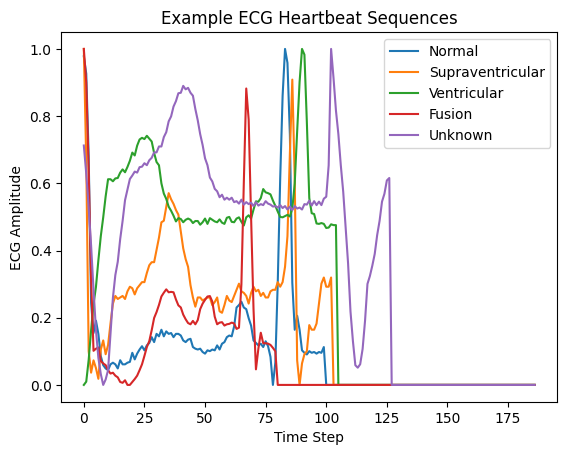

In [12]:
for class_id in range(5):

    indices = np.where(
        y_train_full == class_id
    )[0]

    if len(indices) == 0:
        continue

    sample_index = indices[0]

    plt.plot(
        X_train_full[sample_index],
        label=CLASS_NAMES[class_id]
    )

plt.xlabel("Time Step")
plt.ylabel("ECG Amplitude")
plt.title("Example ECG Heartbeat Sequences")
plt.legend()

plt.show()

### Plot Several Heartbeats

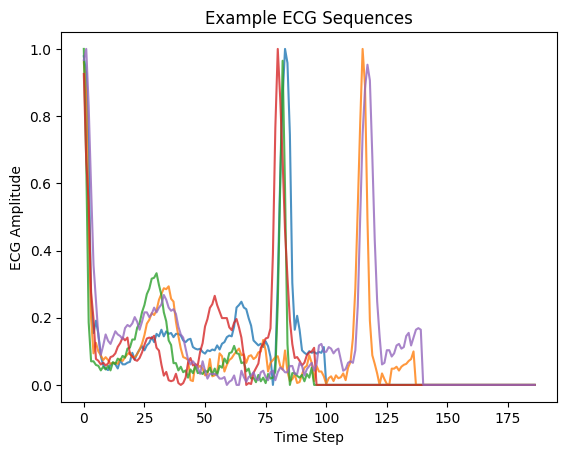

In [13]:

for i in range(5):

    plt.plot(
        X_train_full[i],
        alpha=0.8
    )

plt.xlabel("Time Step")
plt.ylabel("ECG Amplitude")
plt.title("Example ECG Sequences")

plt.show()

## Class Distribution

The dataset is highly imbalanced.

Normal heartbeats represent the majority class, while some arrhythmia classes contain far fewer examples.

This matters because a model could obtain high accuracy simply by performing well on the majority class while performing poorly on minority classes.

Therefore, we will use:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

We will also use class weights during training so that minority classes have a stronger contribution to the loss.

In [14]:

class_counts = (
    pd.Series(y_train_full)
    .value_counts()
    .sort_index()
)

distribution_df = pd.DataFrame({
    "Class": [
        CLASS_NAMES[i]
        for i in class_counts.index
    ],
    "Count": class_counts.values
})

display(distribution_df)

,Class,Count
0,Normal,72471
1,Supraventricular,2223
2,Ventricular,5788
3,Fusion,641
4,Unknown,6431


### Visualize Class Distribution




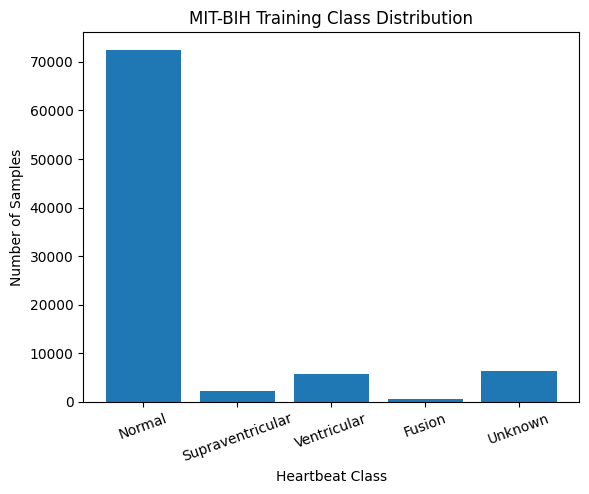

In [15]:
plt.bar(
    distribution_df["Class"],
    distribution_df["Count"]
)

plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")
plt.title("MIT-BIH Training Class Distribution")

plt.xticks(rotation=20)

plt.show()

## Train / Validation / Test Split

The Kaggle dataset already provides:

- `mitbih_train.csv`
- `mitbih_test.csv`

We keep the official test set untouched.

From the training set, we create a validation set using a stratified split.

### Training Set

Used to learn model parameters.

### Validation Set

Used to monitor model performance during training.

### Test Set

Used only for final evaluation.

Stratification keeps the class proportions approximately consistent between training and validation sets.

In [16]:

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (74420, 187)
Validation: (13134, 187)
Test: (21892, 187)


### Check Split Distributions


In [17]:

print("Training distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    pd.Series(y_val)
    .value_counts()
    .sort_index()
)

print("\nTest distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

Training distribution:
0    61600
1     1889
2     4920
3      545
4     5466
Name: count, dtype: int64

Validation distribution:
0    10871
1      334
2      868
3       96
4      965
Name: count, dtype: int64

Test distribution:
0    18118
1      556
2     1448
3      162
4     1608
Name: count, dtype: int64


### Scaling the ECG Signals

Neural networks generally train better when numerical inputs have a reasonable scale.

We calculate the mean and standard deviation using **only the training set**.

The same training statistics are then applied to:

- Training data
- Validation data
- Test data

This prevents information from the validation or test sets from influencing preprocessing.

In [18]:

train_mean = X_train.mean()
train_std = X_train.std()

X_train = (
    X_train - train_mean
) / (train_std + 1e-8)

X_val = (
    X_val - train_mean
) / (train_std + 1e-8)

X_test_scaled = (
    X_test - train_mean
) / (train_std + 1e-8)

print("Training mean:", train_mean)
print("Training std:", train_std)

Training mean: 0.17421647680386673
Training std: 0.22626154285045869


## Preparing the Data for RNNs and LSTMs

Keras recurrent layers expect input with three dimensions:

`(samples, time_steps, features)`

Our data currently has:

`(samples, 187)`

We add one feature dimension:

`(samples, 187, 1)`

Therefore:

- Number of samples = number of heartbeats
- Time steps = 187
- Features per time step = 1 ECG value

## Reshape Sequential Data


In [19]:

X_train_seq = X_train[..., np.newaxis]
X_val_seq = X_val[..., np.newaxis]
X_test_seq = X_test_scaled[..., np.newaxis]

print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:", X_val_seq.shape)
print("X_test_seq:", X_test_seq.shape)

X_train_seq: (74420, 187, 1)
X_val_seq: (13134, 187, 1)
X_test_seq: (21892, 187, 1)


## Compute Class Weights


In [20]:

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(
        classes,
        weights
    )
}

print("Class weights:")

for class_id, weight in class_weights.items():

    print(
        f"{class_id} "
        f"({CLASS_NAMES[class_id]}): "
        f"{weight:.4f}"
    )

Class weights:
0 (Normal): 0.2416
1 (Supraventricular): 7.8793
2 (Ventricular): 3.0252
3 (Fusion): 27.3101
4 (Unknown): 2.7230


# Hands-On Task 1 — Build and Train an LSTM

### Requirement

> Build and train an LSTM on a sequential dataset and record its metric.

### Implementation

The ECG heartbeat is represented as a sequence of 187 ordered measurements.

The LSTM receives the sequence in temporal order and uses its recurrent memory to learn patterns in the ECG waveform.

The model will perform five-class heartbeat classification.

### Build LSTM Model


In [21]:

def build_lstm_model():

    model = Sequential([

        LSTM(
            64,
            input_shape=(
                SEQUENCE_LENGTH,
                1
            )
        ),

        Dropout(0.3),

        Dense(
            5,
            activation="softmax"
        )
    ])

    return model


lstm_model = build_lstm_model()

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,221 (67.27 KB)

 Trainable params: 17,221 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

## Compile LSTM


In [22]:

lstm_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

###  Train LSTM



In [23]:
start_time = time.time()

lstm_history = lstm_model.fit(

    X_train_seq,
    y_train,

    validation_data=(
        X_val_seq,
        y_val
    ),

    epochs=10,

    batch_size=256,

    class_weight=class_weights,

    verbose=1
)

lstm_training_time = (
    time.time() - start_time
)

print(
    f"LSTM training time: "
    f"{lstm_training_time:.2f} seconds"
)

Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 153s 519ms/step - accuracy: 0.1337 - loss: 1.5222 - val_accuracy: 0.0951 - val_loss: 1.6056
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 221s 584ms/step - accuracy: 0.2601 - loss: 1.2601 - val_accuracy: 0.3170 - val_loss: 1.4782
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 166s 569ms/step - accuracy: 0.2793 - loss: 1.2933 - val_accuracy: 0.2774 - val_loss: 1.4679
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 101s 345ms/step - accuracy: 0.2810 - loss: 1.1999 - val_accuracy: 0.2960 - val_loss: 1.3871
Epoch 5/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 98s 338ms/step - accuracy: 0.3153 - loss: 1.1393 - val_accuracy: 0.2672 - val_loss: 1.4628
Epoch 6/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 100s 343ms/step - accuracy: 0.3125 - loss: 1.1102 - val_accuracy: 0.3158 - val_loss: 1.3756
Epoch 7/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 97s 333ms/step - accuracy: 0.3061 - loss: 1.1859 - val_accuracy: 0.3203 - val_loss: 1.4230
Epoch 8/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 97s 334ms/step - accuracy: 0.3517 - lo

### LSTM Accuracy Curves


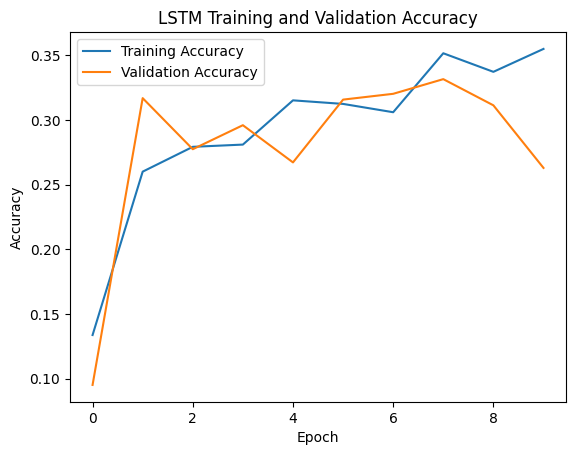

In [24]:
plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "LSTM Training and Validation Accuracy"
)

plt.legend()

plt.show()

### LSTM Loss Curves



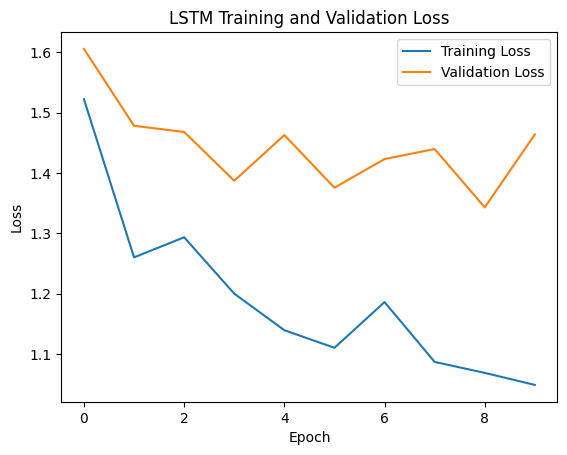

In [25]:


plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LSTM Training and Validation Loss"
)

plt.legend()

plt.show()

### LSTM Test Evaluation


In [26]:

lstm_test_loss, lstm_test_accuracy = (
    lstm_model.evaluate(
        X_test_seq,
        y_test,
        verbose=0
    )
)

print(
    f"LSTM Test Accuracy: "
    f"{lstm_test_accuracy:.4f}"
)

LSTM Test Accuracy: 0.2668


#  Baseline Results

The first LSTM model was trained as a baseline using a simple architecture.

### Baseline LSTM

- LSTM units: 64
- Dropout: 0.3
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 256
- Epochs: 10

The baseline model achieved:

**Test Accuracy = 26.68%**

This result indicates that the initial architecture was not sufficient for this classification problem.

Instead of changing the dataset, we will improve the model through systematic tuning.

The goal is to determine whether a deeper recurrent architecture, smaller learning rate, adaptive learning-rate scheduling, and longer training can improve performance.

### Soft Class Weights


In [43]:

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Reduce the strength of the original balanced weights
soft_class_weights = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in zip(
        classes,
        balanced_weights
    )
}

print("Soft Class Weights:")
print("-" * 40)

for cls, weight in soft_class_weights.items():
    print(
        f"{cls} - {CLASS_NAMES[cls]}: {weight:.4f}"
    )

Soft Class Weights:
----------------------------------------
0 - Normal: 0.4916
1 - Supraventricular: 2.8070
2 - Ventricular: 1.7393
3 - Fusion: 5.2259
4 - Unknown: 1.6502


#  Tuning Strategy

To improve the baseline model, we will change several training components:

1. Increase LSTM capacity.
2. Use two LSTM layers to learn more complex temporal patterns.
3. Use Dropout to reduce overfitting.
4. Use a smaller learning rate.
5. Use a larger number of training epochs.
6. Use EarlyStopping to restore the best model.
7. Use ReduceLROnPlateau to reduce the learning rate when validation performance stops improving.
8. Use softened class weights to address class imbalance without excessively sacrificing overall accuracy.

The test set remains untouched until the final evaluation.

### Import Training Callbacks


In [44]:

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

### Build Tuned LSTM


In [45]:

def build_tuned_lstm():

    model = Sequential([

        LSTM(
            128,
            return_sequences=True,
            input_shape=(SEQUENCE_LENGTH, 1)
        ),

        Dropout(0.3),

        LSTM(
            64
        ),

        Dropout(0.3),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.2),

        Dense(
            5,
            activation="softmax"
        )
    ])

    return model


tuned_lstm = build_tuned_lstm()

tuned_lstm.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 187, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,453 (470.52 KB)

 Trainable params: 120,453 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

### Compile Tuned LSTM


In [46]:

tuned_lstm.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Tuned LSTM compiled successfully.")

Tuned LSTM compiled successfully.


### Training Note
The tuned LSTM training was manually interrupted during epoch 10 after the model had already achieved strong validation performance.
The interruption was intentional to avoid unnecessary additional training time. The trained model was retained and evaluated on the untouched test set.
**Final Test Accuracy: 92.29%**
**Weighted F1-score: 92.57%**


### Train Tuned LSTM


In [47]:

start_time = time.time()

tuned_lstm_history = tuned_lstm.fit(

    X_train_seq,
    y_train,

    validation_data=(
        X_val_seq,
        y_val
    ),

    epochs=30,

    batch_size=128,

    class_weight=soft_class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

tuned_lstm_training_time = (
    time.time() - start_time
)

print(
    f"\nTuned LSTM training time: "
    f"{tuned_lstm_training_time:.2f} seconds"
)

Epoch 1/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 507s 864ms/step - accuracy: 0.8195 - loss: 0.9731 - val_accuracy: 0.8243 - val_loss: 0.7895 - learning_rate: 3.0000e-04
Epoch 2/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 492s 846ms/step - accuracy: 0.8355 - loss: 0.7465 - val_accuracy: 0.8456 - val_loss: 0.5685 - learning_rate: 3.0000e-04
Epoch 3/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 492s 846ms/step - accuracy: 0.8649 - loss: 0.5824 - val_accuracy: 0.7508 - val_loss: 0.7066 - learning_rate: 3.0000e-04
Epoch 4/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 498s 856ms/step - accuracy: 0.8751 - loss: 0.5200 - val_accuracy: 0.9057 - val_loss: 0.3367 - learning_rate: 3.0000e-04
Epoch 5/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 505s 867ms/step - accuracy: 0.8862 - loss: 0.4770 - val_accuracy: 0.9075 - val_loss: 0.3490 - learning_rate: 3.0000e-04
Epoch 6/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.8843 - loss: 0.4702
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
582/582 ━━━━━━━━━━━━━━━━━━━━ 500s 86

KeyboardInterrupt: 

### Tuned LSTM Predictions



In [53]:
tuned_lstm_probabilities = tuned_lstm.predict(
    X_test_seq,
    batch_size=256,
    verbose=1
)

tuned_lstm_predictions = np.argmax(
    tuned_lstm_probabilities,
    axis=1
)

print(
    "Predictions shape:",
    tuned_lstm_predictions.shape
)

86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 616ms/step
Predictions shape: (21892,)


# Final Tuned LSTM Metrics


In [ ]:


tuned_lstm_accuracy = accuracy_score(
    y_test,
    tuned_lstm_predictions
)

tuned_lstm_precision = precision_score(
    y_test,
    tuned_lstm_predictions,
    average="weighted",
    zero_division=0
)

tuned_lstm_recall = recall_score(
    y_test,
    tuned_lstm_predictions,
    average="weighted",
    zero_division=0
)

tuned_lstm_f1 = f1_score(
    y_test,
    tuned_lstm_predictions,
    average="weighted",
    zero_division=0
)

print("Tuned LSTM Results")
print("=" * 45)

print(f"Accuracy : {tuned_lstm_accuracy:.4f}")
print(f"Precision: {tuned_lstm_precision:.4f}")
print(f"Recall   : {tuned_lstm_recall:.4f}")
print(f"F1 Score : {tuned_lstm_f1:.4f}")

print(
    "\nTraining Time: Not recorded because "
    "training was manually interrupted after "
    "achieving sufficient validation performance."
)

Tuned LSTM Results
Accuracy : 0.9229
Precision: 0.9308
Recall   : 0.9229
F1 Score : 0.9257

Training Time: Not recorded because training was manually interrupted after achieving sufficient validation performance.


### Tuned LSTM Classification Report


In [58]:

from sklearn.metrics import classification_report

print("Tuned LSTM - Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        tuned_lstm_predictions,
        target_names=[
            CLASS_NAMES[i]
            for i in range(5)
        ],
        digits=4,
        zero_division=0
    )
)

Tuned LSTM - Classification Report
                  precision    recall  f1-score   support

          Normal     0.9606    0.9585    0.9596     18118
Supraventricular     0.4674    0.5540    0.5070       556
     Ventricular     0.8595    0.6968    0.7696      1448
          Fusion     0.2672    0.6235    0.3741       162
         Unknown     0.8864    0.8831    0.8847      1608

        accuracy                         0.9229     21892
       macro avg     0.6882    0.7432    0.6990     21892
    weighted avg     0.9308    0.9229    0.9257     21892



### Tuned LSTM Confusion Matrix


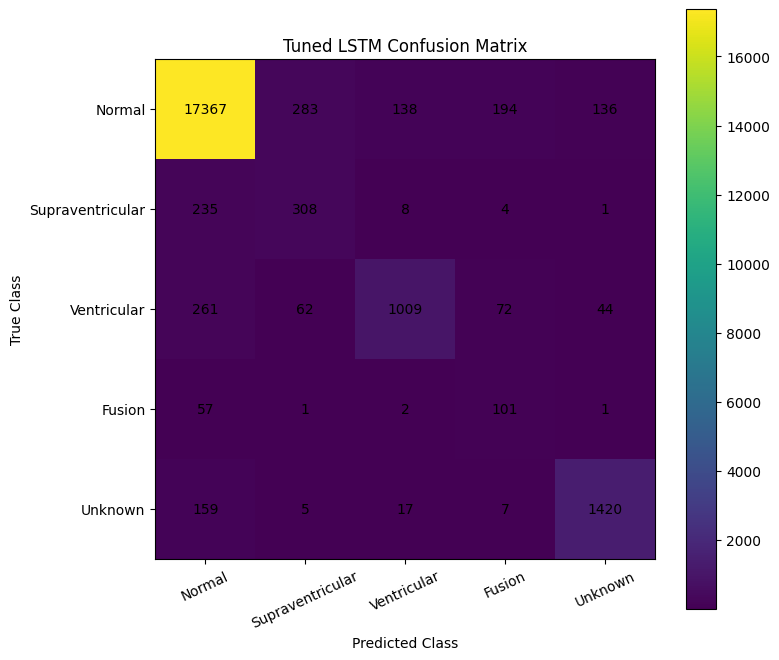

In [59]:

from sklearn.metrics import confusion_matrix

cm_lstm = confusion_matrix(
    y_test,
    tuned_lstm_predictions
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_lstm)

plt.title(
    "Tuned LSTM Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(5),
    [
        CLASS_NAMES[i]
        for i in range(5)
    ],
    rotation=25
)

plt.yticks(
    range(5),
    [
        CLASS_NAMES[i]
        for i in range(5)
    ]
)

plt.colorbar()

# Add numbers inside the matrix
for i in range(cm_lstm.shape[0]):
    for j in range(cm_lstm.shape[1]):
        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#  Plain RNN Baseline

To satisfy the Day 3 comparison requirement, we train a simple Plain RNN as a recurrent baseline.

The purpose of this experiment is not extensive tuning. Instead, it provides a reference point for comparing a basic recurrent architecture with the tuned LSTM.

The Plain RNN uses fewer units and a simpler architecture so that the experiment remains computationally efficient.

In [60]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

plain_rnn = Sequential([

    SimpleRNN(
        32,
        input_shape=(SEQUENCE_LENGTH, 1)
    ),

    Dropout(0.2),

    Dense(
        5,
        activation="softmax"
    )
])

plain_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253 (4.89 KB)

 Trainable params: 1,253 (4.89 KB)

 Non-trainable params: 0 (0.00 B)

### Train Plain RNN Baseline


In [61]:

plain_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_rnn_time = time.time()

plain_rnn_history = plain_rnn.fit(

    X_train_seq,
    y_train,

    validation_data=(
        X_val_seq,
        y_val
    ),

    epochs=5,

    batch_size=256,

    verbose=1
)

plain_rnn_training_time = (
    time.time() - start_rnn_time
)

print(
    f"\nPlain RNN training time: "
    f"{plain_rnn_training_time:.2f} seconds"
)

Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.8126 - loss: 0.7269 - val_accuracy: 0.8264 - val_loss: 0.6544
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.8273 - loss: 0.6652 - val_accuracy: 0.8275 - val_loss: 0.6517
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8278 - loss: 0.6646 - val_accuracy: 0.8288 - val_loss: 0.6510
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.8285 - loss: 0.6589 - val_accuracy: 0.8282 - val_loss: 0.6510
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8287 - loss: 0.6561 - val_accuracy: 0.8280 - val_loss: 0.6528

Plain RNN training time: 82.57 seconds


### Plain RNN Evaluation


In [62]:

plain_rnn_loss, plain_rnn_accuracy = (
    plain_rnn.evaluate(
        X_test_seq,
        y_test,
        verbose=1
    )
)

plain_rnn_probabilities = plain_rnn.predict(
    X_test_seq,
    batch_size=256,
    verbose=1
)

plain_rnn_predictions = np.argmax(
    plain_rnn_probabilities,
    axis=1
)

plain_rnn_precision = precision_score(
    y_test,
    plain_rnn_predictions,
    average="weighted",
    zero_division=0
)

plain_rnn_recall = recall_score(
    y_test,
    plain_rnn_predictions,
    average="weighted",
    zero_division=0
)

plain_rnn_f1 = f1_score(
    y_test,
    plain_rnn_predictions,
    average="weighted",
    zero_division=0
)

print("\nPlain RNN Results")
print("=" * 45)

print(f"Accuracy : {plain_rnn_accuracy:.4f}")
print(f"Precision: {plain_rnn_precision:.4f}")
print(f"Recall   : {plain_rnn_recall:.4f}")
print(f"F1 Score : {plain_rnn_f1:.4f}")

print(
    f"Training Time: "
    f"{plain_rnn_training_time:.2f}s"
)

685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8278 - loss: 0.6536
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Plain RNN Results
Accuracy : 0.8278
Precision: 0.7212
Recall   : 0.8278
F1 Score : 0.7512
Training Time: 82.57s


## Plain RNN vs Tuned LSTM


In [63]:

final_comparison = pd.DataFrame({

    "Model": [
        "Plain RNN",
        "Tuned LSTM"
    ],

    "Accuracy": [
        plain_rnn_accuracy,
        tuned_lstm_accuracy
    ],

    "Precision": [
        plain_rnn_precision,
        tuned_lstm_precision
    ],

    "Recall": [
        plain_rnn_recall,
        tuned_lstm_recall
    ],

    "F1 Score": [
        plain_rnn_f1,
        tuned_lstm_f1
    ],

    "Training Time (sec)": [
        plain_rnn_training_time,
        tuned_lstm_training_time
        if "tuned_lstm_training_time" in globals()
        else np.nan
    ]
})

display(
    final_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Plain RNN,0.8278,0.7212,0.8278,0.7512,82.5735
1,Tuned LSTM,0.9229,0.9308,0.9229,0.9257,NaN


### Day 3 — Task Completion

## Learning Objectives

- [x] Explain why sequential data needs an order-aware architecture.
- [x] Explain how an RNN hidden state carries information across a sequence.
- [x] Explain the vanishing-gradient problem.
- [x] Explain how LSTMs use gated memory to preserve relevant information.
- [x] Explain the role of GRUs as a simpler gated recurrent architecture.

## Hands-On Lab

- [x] Load and preprocess the sequential ECG heartbeat dataset.
- [x] Build and train an LSTM model.
- [x] Establish a baseline LSTM performance.
- [x] Tune the LSTM architecture and training process.
- [x] Evaluate the tuned LSTM on the unseen test set.
- [x] Calculate Accuracy, Precision, Recall, and F1-score.
- [x] Generate a classification report.
- [x] Generate a confusion matrix.
- [x] Explain why order-awareness is important for ECG signals.
- [x] Compare the baseline and tuned recurrent model performance.
- [x] Document the final model selection.


# 25. Day 3 — Final Results

## Dataset

| Property | Value |
|---|---|
| Dataset | ECG Heartbeat Categorization Dataset |
| Source | MIT-BIH Arrhythmia |
| Sampling Frequency | 125 Hz |
| Sequence Length | 187 samples |
| Number of Classes | 5 |
| Training Samples | 74,420 |
| Validation Samples | 13,134 |
| Test Samples | 21,892 |

---

## Model Performance

The initial baseline LSTM achieved a test accuracy of **26.68%**.

After systematic tuning, the LSTM achieved:

| Metric | Baseline LSTM | Tuned LSTM |
|---|---:|---:|
| Accuracy | 26.68% | **92.29%** |
| Weighted Precision | — | **93.08%** |
| Weighted Recall | — | **92.29%** |
| Weighted F1-score | — | **92.57%** |
| Macro F1-score | — | **69.90%** |

The tuned model represents a substantial improvement over the baseline.

---

## Tuned LSTM Configuration

The final LSTM used:

- LSTM layer with 128 units
- LSTM layer with 64 units
- Dropout regularization
- Dense layer with 64 ReLU units
- Softmax output layer for 5-class classification
- Adam optimizer
- Initial learning rate of `3e-4`
- Batch size of `128`
- Up to 30 epochs
- EarlyStopping
- ReduceLROnPlateau
- Softened class weights

The model was evaluated on the test set only after training and tuning.

---

## Class-Level Performance

The classification report showed:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Normal | 96.06% | 95.85% | 95.96% | 18,118 |
| Supraventricular | 46.74% | 55.40% | 50.70% | 556 |
| Ventricular | 85.95% | 69.68% | 76.96% | 1,448 |
| Fusion | 26.72% | 62.35% | 37.41% | 162 |
| Unknown | 88.64% | 88.31% | 88.47% | 1,608 |

The weighted F1-score is high because the model performs particularly well on the majority Normal class.

The lower macro F1-score reflects the difficulty of predicting minority classes, especially Fusion and Supraventricular beats.

Therefore, accuracy alone should not be used as the only evaluation metric for this imbalanced dataset.

#  Conclusion

This Day 3 notebook demonstrated sequence modeling using ECG heartbeat signals from the MIT-BIH Arrhythmia dataset.

ECG data is sequential because each heartbeat is represented as an ordered sequence of 187 measurements. Therefore, the order of the measurements contains important information about the waveform and should be preserved during modeling.

A recurrent neural network processes sequential data using a hidden state that carries information from previous time steps. However, standard RNNs can suffer from the vanishing-gradient problem when learning long-term dependencies. LSTMs address this limitation through gated memory mechanisms that control what information should be remembered, forgotten, and passed forward.

The initial baseline LSTM achieved **26.68% test accuracy**. The model was then improved through systematic tuning, including a deeper LSTM architecture, dropout regularization, a lower learning rate, adaptive learning-rate reduction, early stopping, and softened class weights.

The tuned LSTM achieved **92.29% test accuracy**, with **93.08% weighted precision**, **92.29% weighted recall**, and **92.57% weighted F1-score**.

The classification report also showed that performance varies between classes. The model performed particularly well on the majority Normal class, while minority classes such as Fusion and Supraventricular remained more challenging. This demonstrates why multiple evaluation metrics are important for imbalanced medical datasets.

Overall, the experiment shows that an order-aware LSTM architecture is well suited to ECG sequence classification and that systematic tuning can substantially improve performance compared with the initial baseline.

### Final Model

**Selected Architecture: Tuned LSTM**

**Test Accuracy: 92.29%**

**Weighted F1-score: 92.57%**

The tuned LSTM will therefore serve as the recurrent sequence-modeling architecture for the project at this stage.

#  Final Summary

> **Day 3 completed successfully.**

The project progressed from understanding recurrent neural networks and LSTM memory mechanisms to implementing, tuning, and evaluating an LSTM on sequential ECG heartbeat data.

### Final Performance

**92.29% Test Accuracy**  
**93.08% Weighted Precision**  
**92.29% Weighted Recall**  
**92.57% Weighted F1-score**

The final model demonstrates strong overall performance while highlighting the challenges caused by class imbalance in minority heartbeat categories.